#### Team members

1. Mostafa Allahmoradi - 9087818
2. Cemil Caglar Yapici – 9081058
3. Jarius Bedward - 8841640

#### Problem statement: Investigating the Relationship Between High Fat Intake and Heart Disease Risk

Area of Focus:  
Heart disease and obesity remain two of the most critical global health challenges. Diet quality, particularly the consumption of dietary fats, is widely recognized as a primary determinant of these conditions. Higher consumption of dietary fat contributes to the chance of obesity and heart attack. However, it is not clear whether individuals with higher fat intake show a greater likelihood of heart-disease-related conditions, understanding this relationship is essential for designing targeted dietary interventions and improving nutritional guidelines.

#### Research Question: 
Is there a statistically significant difference in daily fat intake between individuals diagnosed with heart disease or obesity and those without these conditions?

#### Research Hypothesis
Null Hypothesis (H₀): Individuals with heart disease or obesity problem have a significantly higher mean daily fat intake compared to individuals without such conditions ($\mu_{disease} > \mu_{healthy}$).

Alternative Hypothesis (H₁): There is no significant relationship between mean daily fat intake between individuals with heart diseases or obesity and those without such conditions($\mu_{disease} \leq \mu_{healthy}$).

#### 100-word summary update of the use case
This study examines whether higher daily fat intake is associated with an increased risk of heart disease or obesity. Using a detailed nutrition and health dataset, the analysis compares fat consumption levels between individuals diagnosed with these conditions and those without them. By statistically evaluating differences in mean daily fat intake, the research aims to clarify whether dietary fat is a meaningful predictor of heart disease or obesity risk. The findings can contribute to improved dietary guidelines, early-risk identification, and personalized nutrition planning. Ultimately, this use case supports public-health efforts to reduce heart-disease and obesity through evidence-based dietary interventions.

#### Import libraries

In [61]:

import pandas as pd
import numpy as np
import importlib
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
# import features as ft
# from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDRegressor
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.feature_selection import SelectKBest, f_classif, RFE
# from sklearn.linear_model import LogisticRegression
# from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import clear_output
import statsmodels.api as sm

import DataExtraction.FileManager as FileManager
importlib.reload(FileManager)

import DataPrepairation.DataPrepairer as DataPrepairer
importlib.reload(DataPrepairer)

import DataAnalysis.DataAnalyzer as DataAnalyzer
importlib.reload(DataAnalyzer)

<module 'DataAnalysis.DataAnalyzer' from 'C:\\Users\\jjbed\\Downloads\\Group_Presentation_5\\DataAnalysis\\DataAnalyzer.py'>

#### Coding etiquette: Start by clearing all output and workspace

In [62]:
# Clear plots
plt.close('all')

# Clear console
clear_output()
# Clean workspace
# %reset -f

#### Load and Explore data

In [63]:
macros_dataset_csv_path = 'data/detailed_meals_macros_.csv'

fileManager = FileManager.FileManager(macros_dataset_csv_path)

# Load the dataset
macros_dataset = fileManager.data

# Display first few rows
print("\nData Set (First 5 Rows): ")
display(macros_dataset.head(5))



# Data analysis and insights
data_analyzer = DataAnalyzer.DataAnalyzer(macros_dataset)
data_analyzer.data_analysis()


✅ Successfully loaded 1698 rows from data/detailed_meals_macros_.csv

Data Set (First 5 Rows): 


,Ages,Gender,Height,Weight,Activity Level,Dietary Preference,Daily Calorie Target,Protein,Sugar,Sodium,...,Dinner Calories,Dinner Protein.1,Dinner Carbohydrates.1,Dinner Fats,Snack Suggestion,Snacks Calories,Snacks Protein,Snacks Carbohydrates,Snacks Fats,Disease
0,25,Male,180,80,Moderately Active,Omnivore,2000,120,125.0,24.0,...,2020.0,60.0,250.0,60.0,Greek yogurt with fruit,150,10,20,5,Weight Gain
1,32,Female,165,65,Lightly Active,Vegetarian,1600,80,100.0,16.0,...,10.0,5.0,31.0,27.0,Apple with almond butter,180,4,30,8,"Weight Gain, Hypertension, Heart Disease"
2,48,Male,175,95,Sedentary,Vegan,2200,100,150.0,20.0,...,326.0,55.0,150.0,15.0,Trail mix,300,8,34,20,Weight Gain
3,55,Female,160,70,Very Active,Omnivore,2500,140,175.0,28.0,...,278.0,20.0,163.0,27.0,Banana with peanut butter,210,5,30,9,Weight Gain
4,62,Male,170,85,Sedentary,Vegetarian,2000,80,125.0,16.0,...,186.0,6.3,186.0,22.0,Fruit and nut mix,250,6,28,15,Weight Gain


 Data Analysis Report:
 - Number of rows: 1698
 - Number of columns: 35
 - Column names: ['Ages', 'Gender', 'Height', 'Weight', 'Activity Level', 'Dietary Preference', 'Daily Calorie Target', 'Protein', 'Sugar', 'Sodium', 'Calories', 'Carbohydrates', 'Fiber', 'Fat', 'Breakfast Suggestion', 'Breakfast Calories', 'Breakfast Protein', 'Breakfast Carbohydrates', 'Breakfast Fats', 'Lunch Suggestion', 'Lunch Calories', 'Lunch Protein', 'Lunch Carbohydrates', 'Lunch Fats', 'Dinner Suggestion', 'Dinner Calories', 'Dinner Protein.1', 'Dinner Carbohydrates.1', 'Dinner Fats', 'Snack Suggestion', 'Snacks Calories', 'Snacks Protein', 'Snacks Carbohydrates', 'Snacks Fats', 'Disease']
 - Data types:
Ages                         int64
Gender                      object
Height                       int64
Weight                       int64
Activity Level              object
Dietary Preference          object
Daily Calorie Target         int64
Protein                      int64
Sugar                     

In [64]:
# Outlier detection
print("Outlier report for numerical columns:")
for column in macros_dataset.columns:
    if macros_dataset[column].dtype in [np.float64, np.int64]:
        data_analyzer.outlier_detection(column)

Outlier report for numerical columns:
✅0 Outliers detected for column 'Ages': []
✅0 Outliers detected for column 'Height': []
✅0 Outliers detected for column 'Weight': []
✅5 Outliers detected for column 'Daily Calorie Target': [1048, 1066, 1166, 1208, 1628]
✅7 Outliers detected for column 'Protein': [1048, 1066, 1091, 1166, 1208, 1512, 1628]
✅0 Outliers detected for column 'Sugar': []
✅7 Outliers detected for column 'Sodium': [1048, 1066, 1091, 1166, 1208, 1512, 1628]
✅11 Outliers detected for column 'Calories': [1048, 1066, 1091, 1166, 1208, 1377, 1512, 1531, 1561, 1628, 1651]
✅0 Outliers detected for column 'Carbohydrates': []
✅0 Outliers detected for column 'Fiber': []
✅4 Outliers detected for column 'Fat': [1066, 1166, 1208, 1628]
✅31 Outliers detected for column 'Breakfast Calories': [41, 91, 100, 128, 186, 196, 227, 246, 263, 309, 361, 476, 590, 601, 629, 667, 683, 693, 726, 738, 764, 789, 960, 1011, 1063, 1127, 1150, 1190, 1537, 1572, 1641]
✅64 Outliers detected for column 'Brea

#### Feature engineering

In [65]:
# Add Height in meters feature
macros_dataset['Height_m'] = macros_dataset['Height'] / 100  # convert cm → m

# Add BMI feature
macros_dataset['BMI'] = macros_dataset['Weight'] / (macros_dataset['Height_m'] ** 2)

# Add Obesity feature
# Target variable for Obesity (1 if BMI >= 30)
macros_dataset['Obesity'] = np.where(macros_dataset['BMI'] >= 30, 1, 0) 

# Add Heart_Disease feature
# Target variable for Heart Disease (1 if has Heart Disease) 
macros_dataset['Heart_Disease'] = np.where(macros_dataset['Disease'].str.contains('Heart', na=False), 1, 0) 

# Converting Activity Level to numeric
macros_dataset['Activity Level'] = macros_dataset['Activity Level'].astype('category').cat.codes

# group presentation 4 portion feature engineering

#Select relevant features
features = [
    'Daily Calorie Target', 'Calories', 'Protein', 'Sugar', 'Sodium',
    'Carbohydrates', 'Fiber', 'Fat', 'Activity Level', 'Dietary Preference'
]
x = macros_dataset[features].copy()
y = macros_dataset['Obesity']

le = LabelEncoder()
for col in ["Activity Level", "Dietary Preference"]:
    x[col] = le.fit_transform(x[col])
#commit
#for group presentation 4 portion
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

macros_dataset.head()


print("Setup Complete")
print("Features matrix shape:", X_scaled.shape)
print("Target distribution (0=not obese), 1=Obese):\n", y.value_counts())
X_scaled.head()


Setup Complete
Features matrix shape: (1698, 10)
Target distribution (0=not obese), 1=Obese):
 Obesity
0    1329
1     369
Name: count, dtype: int64


,Daily Calorie Target,Calories,Protein,Sugar,Sodium,Carbohydrates,Fiber,Fat,Activity Level,Dietary Preference
0,-0.492568,-0.309045,-0.373247,-0.034143,-0.373247,-0.034143,-0.034143,-0.452793,-0.196012,-1.263487
1,-1.208582,-1.254885,-1.123563,-0.749889,-1.123563,-0.749889,-0.749889,-1.386309,-1.001893,1.235039
2,-0.134561,-0.020039,-0.748405,0.681602,-0.748405,0.681602,0.681602,-0.219415,0.609868,0.402197
3,0.402450,0.846981,0.001911,1.397348,0.001911,1.397348,1.397348,0.480722,1.415749,-1.263487
4,-0.492568,-0.668114,-1.123563,-0.034143,-1.123563,-0.034143,-0.034143,-0.686172,0.609868,1.235039


In [66]:
# Handle missing values
data_prepairer = DataPrepairer.DataPrepairer(macros_dataset)
data_prepairer.handle_missing_values()

# Normalize feature names
data_prepairer.normalize_feature_names()

macros_dataset = data_prepairer.data

macros_dataset.head()


 Missing values per column report: Ages                       0
Gender                     0
Height                     0
Weight                     0
Activity Level             0
Dietary Preference         0
Daily Calorie Target       0
Protein                    0
Sugar                      0
Sodium                     0
Calories                   0
Carbohydrates              0
Fiber                      0
Fat                        0
Breakfast Suggestion       0
Breakfast Calories         0
Breakfast Protein          0
Breakfast Carbohydrates    1
Breakfast Fats             0
Lunch Suggestion           0
Lunch Calories             0
Lunch Protein              0
Lunch Carbohydrates        0
Lunch Fats                 0
Dinner Suggestion          0
Dinner Calories            0
Dinner Protein.1           0
Dinner Carbohydrates.1     0
Dinner Fats                0
Snack Suggestion           0
Snacks Calories            0
Snacks Protein             0
Snacks Carbohydrates       0
Snacks F

C:\Users\jjbed\Downloads\Group_Presentation_5\DataPrepairation\DataPrepairer.py:15: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  self.data.iloc[:, 1:] = self.data.iloc[:, 1:].interpolate(


,ages,gender,height,weight,activity_level,dietary_preference,daily_calorie_target,protein,sugar,sodium,...,snack_suggestion,snacks_calories,snacks_protein,snacks_carbohydrates,snacks_fats,disease,height_m,bmi,obesity,heart_disease
0,25,Male,180,80,2,Omnivore,2000,120,125.0,24.0,...,Greek yogurt with fruit,150,10,20,5,Weight Gain,1.80,24.691358,0,0
1,32,Female,165,65,1,Vegetarian,1600,80,100.0,16.0,...,Apple with almond butter,180,4,30,8,"Weight Gain, Hypertension, Heart Disease",1.65,23.875115,0,1
2,48,Male,175,95,3,Vegan,2200,100,150.0,20.0,...,Trail mix,300,8,34,20,Weight Gain,1.75,31.020408,1,0
3,55,Female,160,70,4,Omnivore,2500,140,175.0,28.0,...,Banana with peanut butter,210,5,30,9,Weight Gain,1.60,27.343750,0,0
4,62,Male,170,85,3,Vegetarian,2000,80,125.0,16.0,...,Fruit and nut mix,250,6,28,15,Weight Gain,1.70,29.411765,0,0


### 5.Extensive cleanup and data source preparation

In [67]:
# 5.1.1 – Calculate the missing percentages (ccy)

missing_ratio_ccy = macros_dataset.isna().mean().sort_values(ascending=False)
print("The 15 columns with the highest deficiency rate:\n", missing_ratio_ccy.head(15))

# Threshold: Let's exclude columns with a deficiency rate of 30% or higher (typically, a range of 20–40% is preferred in courses).
MISSING_THRESH = 0.30

drop_cols_missing_ccy = missing_ratio_ccy[missing_ratio_ccy > MISSING_THRESH].index.tolist()
print(f"\nShortage ratio > {MISSING_THRESH:.0%} Number of columns that exist and will be removed: {len(drop_cols_missing_ccy)}")
print(drop_cols_missing_ccy)

# 5.1.2 – remove columns
df_mv_filtered_ccy = macros_dataset.drop(columns=drop_cols_missing_ccy)
print("\nFigure (before/after):", macros_dataset.shape, "->", df_mv_filtered_ccy.shape)


The 15 columns with the highest deficiency rate:
 breakfast_carbohydrates    0.000589
gender                     0.000000
ages                       0.000000
weight                     0.000000
activity_level             0.000000
dietary_preference         0.000000
height                     0.000000
daily_calorie_target       0.000000
protein                    0.000000
sodium                     0.000000
sugar                      0.000000
carbohydrates              0.000000
fiber                      0.000000
fat                        0.000000
calories                   0.000000
dtype: float64

Shortage ratio > 30% Number of columns that exist and will be removed: 0
[]

Figure (before/after): (1698, 39) -> (1698, 39)


##### 5.2 Low Variance Filter: (elimination of low-variance features)

We proceed along two paths below:

-Numeric columns: VarianceThreshold (sklearn)

-Categorical columns: “near-zero variance” intuition (if the dominant category ratio is very high)

In [68]:
# 5.2.0 – Seperation of spice
num_cols_ccy = df_mv_filtered_ccy.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_ccy = df_mv_filtered_ccy.select_dtypes(exclude=[np.number]).columns.tolist()
num_cols_ccy, cat_cols_ccy[:10]


(['ages',
  'height',
  'weight',
  'activity_level',
  'daily_calorie_target',
  'protein',
  'sugar',
  'sodium',
  'calories',
  'carbohydrates',
  'fiber',
  'fat',
  'breakfast_calories',
  'breakfast_protein',
  'breakfast_carbohydrates',
  'breakfast_fats',
  'lunch_calories',
  'lunch_protein',
  'lunch_carbohydrates',
  'lunch_fats',
  'dinner_calories',
  'dinner_protein.1',
  'dinner_carbohydrates.1',
  'dinner_fats',
  'snacks_calories',
  'snacks_protein',
  'snacks_carbohydrates',
  'snacks_fats',
  'height_m',
  'bmi',
  'obesity',
  'heart_disease'],
 ['gender',
  'dietary_preference',
  'breakfast_suggestion',
  'lunch_suggestion',
  'dinner_suggestion',
  'snack_suggestion',
  'disease'])

##### 5.2.1 Low variance filter for numerical columns

In [69]:
# 5.2.1 –
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
#
num_imputer_ccy = SimpleImputer(strategy="median")
X_num_ccy = pd.DataFrame(
    num_imputer_ccy.fit_transform(df_mv_filtered_ccy[num_cols_ccy]),
    columns=num_cols_ccy,
    index=df_mv_filtered_ccy.index
)

#
num_variances_ccy = X_num_ccy.var().sort_values()
print("The 10 columns with the lowest variance:\n", num_variances_ccy.head(10))

# Threshold selection:
# - If features are not standardized, 0.0 is a good starting point (discards completely constant or nearly constant variables)
# - Alternative: discard the bottom 5% (present in the comment line)
MIN_VAR_THRESH = 0.0
# MIN_VAR_THRESH = num_variances_ccy.quantile(0.05)

vt_ccy = VarianceThreshold(threshold=MIN_VAR_THRESH)
X_num_kept = vt_ccy.fit_transform(X_num_ccy)
kept_num_mask_ccy = vt_ccy.get_support()
kept_num_cols_ccy = list(X_num_ccy.columns[kept_num_mask_ccy])
dropped_num_cols_ccy = [c for c in X_num_ccy.columns if c not in kept_num_cols_ccy]

print(f"\nNumber of numerical columns discarded due to low variance: {len(dropped_num_cols_ccy)}")
print(dropped_num_cols_ccy)


The 10 columns with the lowest variance:
 height_m            0.018012
heart_disease       0.141315
obesity             0.170189
activity_level      1.540688
lunch_fats          5.197548
snacks_protein     16.682242
bmi                41.261419
snacks_fats        49.450518
fiber              70.313869
sodium            113.749001
dtype: float64

Number of numerical columns discarded due to low variance: 0
[]


##### 5.2.2 “Near-zero variance” filter for categorical columns

In [70]:
# 5.2.2 –
from collections import Counter

def find_near_zero_var_cats_ccy(df_cat: pd.DataFrame,
                                dominant_thresh: float = 0.95,
                                unique_frac_thresh: float = 0.10):
    drop = []
    stats = {}
    n = len(df_cat)
    for col in df_cat.columns:
        vc = df_cat[col].astype("object")
        # To avoid thinking of missing values as a single category, let's exclude NaNs from the most frequent category count.
        counts = Counter([x for x in vc.dropna().tolist()])
        if n == 0:
            continue
        if counts:
            dom = counts.most_common(1)[0][1] / n
        else:
            dom = 1.0  # If all of them NaN, we count them near-zero in practice
        unique_frac = vc.nunique(dropna=True) / n
        stats[col] = {"dominant_ratio": dom, "unique_frac": unique_frac}
        if (dom >= dominant_thresh) or (unique_frac <= unique_frac_thresh):
            drop.append(col)
    return drop, pd.DataFrame(stats).T.sort_values("dominant_ratio", ascending=False)

drop_cat_cols_ccy, cat_stats_ccy = find_near_zero_var_cats_ccy(df_mv_filtered_ccy[cat_cols_ccy])
print("Candidate categorical columns that could have near-zero variance:\n", drop_cat_cols_ccy)
cat_stats_ccy.head(10)


Candidate categorical columns that could have near-zero variance:
 ['gender', 'dietary_preference', 'breakfast_suggestion', 'snack_suggestion', 'disease']


,dominant_ratio,unique_frac
disease,0.772674,0.007656
gender,0.507656,0.001178
dietary_preference,0.332155,0.002356
snack_suggestion,0.174323,0.065960
breakfast_suggestion,0.123675,0.071260
dinner_suggestion,0.103062,0.104240
lunch_suggestion,0.094817,0.111896


##### 5.2.3 Create the final data frame

In [71]:
# 5.2.3 – Remove all low-variance ones and summarize
df_lowvar_filtered_ccy = df_mv_filtered_ccy.drop(columns=dropped_num_cols_ccy + drop_cat_cols_ccy)

print("\nFigure (before/after):", df_mv_filtered_ccy.shape, "->", df_lowvar_filtered_ccy.shape)

feature_drop_report_ccy = {
    "dropped_missing_cols": drop_cols_missing_ccy,
    "dropped_low_variance_num": dropped_num_cols_ccy,
    "dropped_low_variance_cat": drop_cat_cols_ccy
}
feature_drop_report_ccy



Figure (before/after): (1698, 39) -> (1698, 34)


{'dropped_missing_cols': [],
 'dropped_low_variance_num': [],
 'dropped_low_variance_cat': ['gender',
  'dietary_preference',
  'breakfast_suggestion',
  'snack_suggestion',
  'disease']}

#### 5.2.4 High Correlation Filter

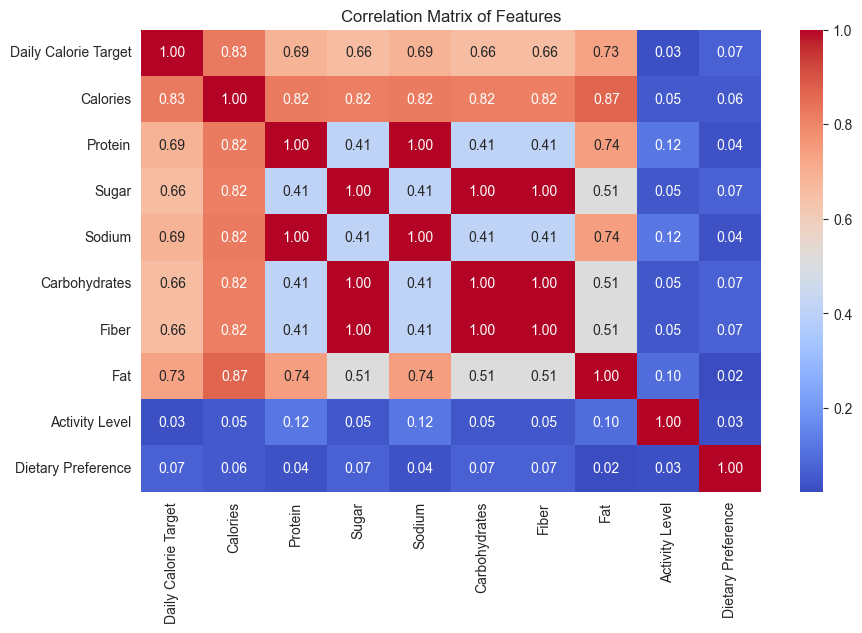

 Highly correlated features (correlation > 0.8):
['Calories', 'Protein', 'Sugar', 'Sodium', 'Carbohydrates', 'Fiber', 'Fat']

Remaining features after filtering:
['Daily Calorie Target', 'Activity Level', 'Dietary Preference']


In [72]:

#Compute correlation matrix
corr_matrix = X_scaled.corr().abs()

#Visualize correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

#Identify highly correlated features (correlation > 0.8)

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

print(" Highly correlated features (correlation > 0.9):")
print(high_corr_features if high_corr_features else "No highly correlated features found.")

# Drop correlated features for next steps
X_corr_filtered = X_scaled.drop(columns=high_corr_features, errors='ignore')
print("\nRemaining features after filtering:")
print(X_corr_filtered.columns.tolist())


#### 5.2.5 Principal Component Analysis

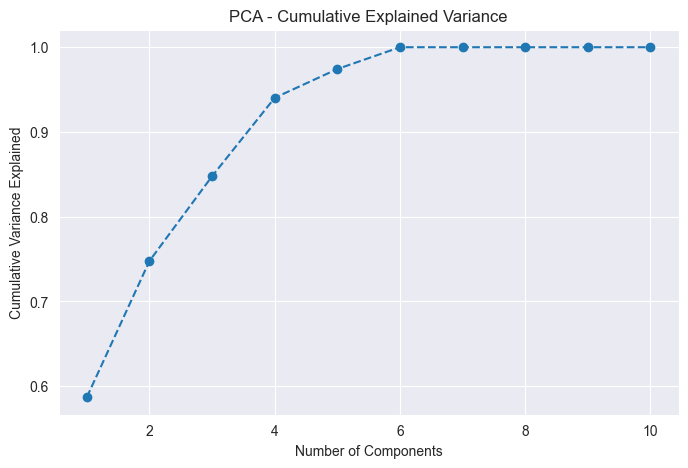

🔍 PCA Component Loadings (Top 3 Components):


,Daily Calorie Target,Calories,Protein,Sugar,Sodium,Carbohydrates,Fiber,Fat,Activity Level,Dietary Preference
0,0.356349,0.409744,0.328394,0.352740,0.328394,0.352740,0.352740,0.338854,-0.01904,-0.031284
1,0.072169,0.051729,0.425361,-0.392300,0.425361,-0.392300,-0.392300,0.251259,-0.31622,0.073676
2,-0.035319,0.009624,-0.071125,0.076948,-0.071125,0.076948,0.076948,-0.004358,-0.26669,0.948492


In [73]:
from sklearn.decomposition import PCA

#Fit PCA on scaled features

pca = PCA()
pca.fit(X_scaled)


#Explained Variance Ratio
explained_var = np.cumsum(pca.explained_variance_ratio_)

#Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linestyle='--')
plt.title("PCA - Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True)
plt.show()

#Display top PCA Components

loadings = pd.DataFrame(pca.components_, columns=x.columns)
print("🔍 PCA Component Loadings (Top 3 Components):")
display(loadings.head(3))

#### 5.2.6 Random Forest Tree

Random Forest Accuracy: 0.6911764705882353

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81       266
           1       0.23      0.18      0.20        74

    accuracy                           0.69       340
   macro avg       0.51      0.51      0.50       340
weighted avg       0.66      0.69      0.68       340


Confusion Matrix:
 [[222  44]
 [ 61  13]]


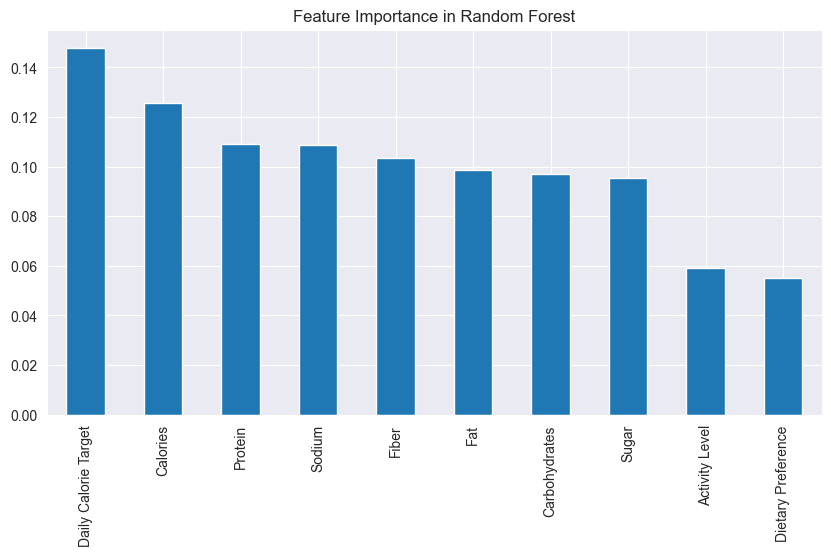

In [74]:


# Split data
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(x_train, y_train)

# Predictions and Evaluation
y_pred = rf_model.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature Importance plot
importances = pd.Series(rf_model.feature_importances_, index=x_train.columns)
importances.sort_values(ascending=False).plot(kind="bar", figsize=(10, 5), title="Feature Importance in Random Forest")
plt.show()


# 5.2.7 Backword/Forward Feature Selection

In [75]:
from sklearn.linear_model import LogisticRegression

# Uses logistic regression as estimator

model = LogisticRegression(max_iter=500)

#Apply rfe to select top 5 features
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X_corr_filtered, y)

selected_features = X_corr_filtered.columns[rfe.support_].tolist()

print("Top features Selected")
print(selected_features)

#Create reduce dataset for modelling

X_selected= X_corr_filtered[selected_features]
X_selected.head()

Top features Selected
['Daily Calorie Target', 'Activity Level', 'Dietary Preference']


C:\Users\jjbed\Downloads\Group_Presentation_5\.venv\Lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=5 > n_features=3. There will be no feature selection and all features will be kept.
  warnings.warn(


,Daily Calorie Target,Activity Level,Dietary Preference
0,-0.492568,-0.196012,-1.263487
1,-1.208582,-1.001893,1.235039
2,-0.134561,0.609868,0.402197
3,0.402450,1.415749,-1.263487
4,-0.492568,0.609868,1.235039


#### 5.2.8 Box-Cox Transformation

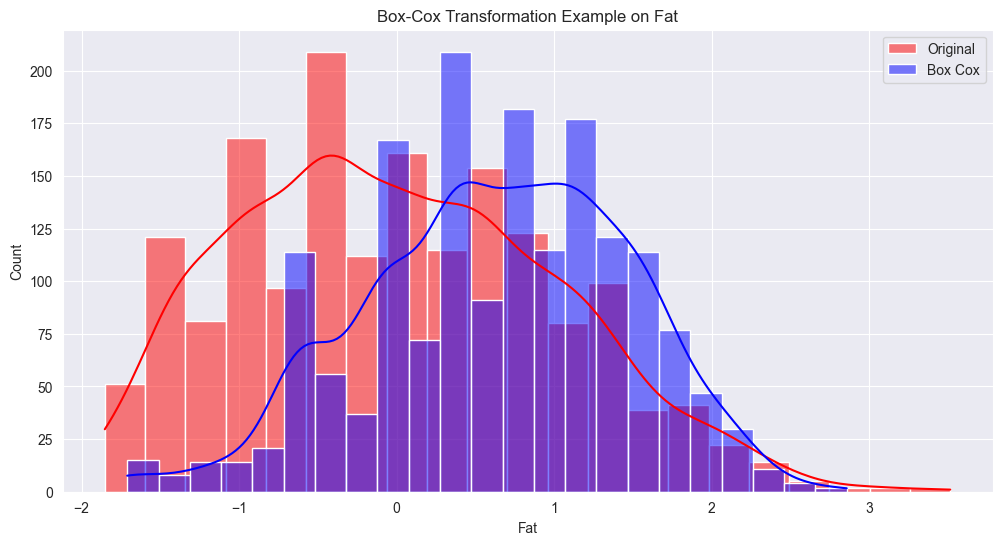

Box-Cox Transformation complete.


,Daily Calorie Target,Calories,Protein,Sugar,Sodium,Carbohydrates,Fiber,Fat,Activity Level,Dietary Preference
0,0.398971,0.702620,0.293264,0.747439,0.293264,0.747439,0.747439,0.372069,-0.196012,-1.263487
1,-0.303853,-0.146316,-0.494710,0.141037,-0.494710,0.141037,0.141037,-0.614918,-1.001893,1.235039
2,0.691884,0.920470,-0.063026,1.260519,-0.063026,1.260519,1.260519,0.568448,0.609868,0.402197
3,1.088125,1.507214,0.604651,1.716114,0.604651,1.716114,1.716114,1.096751,1.415749,-1.263487
4,0.398971,0.410034,-0.494710,0.747439,-0.494710,0.747439,0.747439,0.161521,0.609868,1.235039


In [76]:
from scipy.stats import boxcox

# Apply  Box-cox only to positive continuous variables
numeric_cols = ["Daily Calorie Target", 'Calories', 'Protein', 'Sugar', 'Sodium', 'Carbohydrates', 'Fiber', 'Fat' ]
X_boxcox = X_scaled.copy()

for col in numeric_cols:
    min_val = X_boxcox[col].min()
    if min_val <=0:
        X_boxcox[col] = X_boxcox[col] - min_val + 1e-6 # shift to make all positive values
    X_boxcox[col], _ = boxcox(X_boxcox[col])




plt.figure(figsize=(12, 6))
sns.histplot(X_scaled['Fat'], kde=True, label='Original', color='red', alpha=0.5)
sns.histplot(X_boxcox['Fat'], kde=True, label='Box Cox', color='blue', alpha=0.5)
plt.title('Box-Cox Transformation Example on Fat')
plt.legend()
plt.show()

print("Box-Cox Transformation complete.")
X_boxcox.head()




##### Tukey's Ladder

In [77]:
# 5.3.0 –
import numpy as np, pandas as pd

try:
    base_df_ccy = df_lowvar_filtered_ccy.copy()
except NameError:
    base_df_ccy = df.copy()

# 5.3.1 – Numerical columns and initial skewness
num_cols_ccy = base_df_ccy.select_dtypes(include=[np.number]).columns.tolist()
skew_before_ccy = base_df_ccy[num_cols_ccy].skew().sort_values(ascending=False)
print("The 10 most skewed numerical columns (first):\n", skew_before_ccy.head(10))

# Candidate columns: |skew| > 1 (you can set it to 0.8/1.5, etc. if you want)
SKEW_THRESH = 1.0
skewed_cols_ccy = skew_before_ccy[skew_before_ccy.abs() > SKEW_THRESH].index.tolist()
print("\nNumber of columns to be applied:", len(skewed_cols_ccy))
print(skewed_cols_ccy)


The 10 most skewed numerical columns (first):
 dinner_protein.1           12.939795
dinner_fats                11.380636
breakfast_protein          10.723077
lunch_carbohydrates         5.244070
dinner_carbohydrates.1      5.132418
lunch_protein               4.565463
breakfast_calories          4.447732
breakfast_carbohydrates     2.979638
dinner_calories             2.569688
lunch_calories              1.789961
dtype: float64

Number of columns to be applied: 12
['dinner_protein.1', 'dinner_fats', 'breakfast_protein', 'lunch_carbohydrates', 'dinner_carbohydrates.1', 'lunch_protein', 'breakfast_calories', 'breakfast_carbohydrates', 'dinner_calories', 'lunch_calories', 'heart_disease', 'obesity']


In [78]:
# 5.3.2 – Helpers: positive structure + transformation + selecting the best lambda
def _make_positive_ccy(s: pd.Series, eps: float = 1e-9):
    s = s.astype(float)
    minv = s.min()
    offset = (1 - minv) if minv <= 0 else 0.0
    return s + offset + eps, offset

def _tukey_apply_ccy(s_pos: pd.Series, lam: float):
    if lam == 0:
        return np.log(s_pos)           # log
    else:
        return np.power(s_pos, lam)    # x^λ (negative λ -> 1/x^{|λ|})

def tukey_best_lambda_ccy(s: pd.Series, lambdas=None):
    if lambdas is None:
        lambdas = [-2, -1, -0.5, 0, 0.5, 1, 2]
    s_pos, offset = _make_positive_ccy(s)
    cand = {}
    for lam in lambdas:
        tr = pd.Series(_tukey_apply_ccy(s_pos, lam), index=s.index)
        cand[lam] = tr
    # |skew| the smallest lambda
    best_lam = min(cand, key=lambda L: abs(cand[L].skew()))
    return cand[best_lam], best_lam, offset


In [79]:
# 5.3.3 – Apply and report (ccy)
df_tukey_ccy = base_df_ccy.copy()
tukey_meta_ccy = {}

for col in skewed_cols_ccy:
    transformed, lam, offset = tukey_best_lambda_ccy(df_tukey_ccy[col])
    df_tukey_ccy[col] = transformed
    tukey_meta_ccy[col] = {"lambda": lam, "offset_added": offset}

# 5.3.4 – Before/After distortion comparison
skew_after_ccy = df_tukey_ccy[skewed_cols_ccy].skew().sort_values(ascending=False)

tukey_report_ccy = pd.DataFrame({
    "skew_before": skew_before_ccy.loc[skewed_cols_ccy],
    "skew_after":  skew_after_ccy,
    "lambda":      [tukey_meta_ccy[c]["lambda"] for c in skewed_cols_ccy],
    "offset":      [tukey_meta_ccy[c]["offset_added"] for c in skewed_cols_ccy],
}).sort_values("skew_before", ascending=False)

print("\nTukey Ladder report (in order of importance):")
display(tukey_report_ccy.head(20))

print("\nFigure (before/after):", base_df_ccy.shape, "->", df_tukey_ccy.shape)



Tukey Ladder report (in order of importance):


,skew_before,skew_after,lambda,offset
dinner_protein.1,12.939795,-0.796306,0.5,1.0
dinner_fats,11.380636,-0.267600,0.5,1.0
breakfast_protein,10.723077,-1.396060,0.0,1.0
lunch_carbohydrates,5.244070,-0.384726,0.5,1.0
dinner_carbohydrates.1,5.132418,0.137813,0.0,1.0
lunch_protein,4.565463,0.810914,-2.0,1.0
breakfast_calories,4.447732,0.925959,0.0,1.0
breakfast_carbohydrates,2.979638,-0.843334,0.0,1.0
dinner_calories,2.569688,0.688176,0.0,1.0
lunch_calories,1.789961,0.140718,0.5,1.0



Figure (before/after): (1698, 34) -> (1698, 34)


#### Hypothesis Testing: Test if Fat intake is associated with Heart Disease patients

Mean fat intake (group with heart disease): 40.52 g
Mean fat intake (group without heart disease): 75.69 g


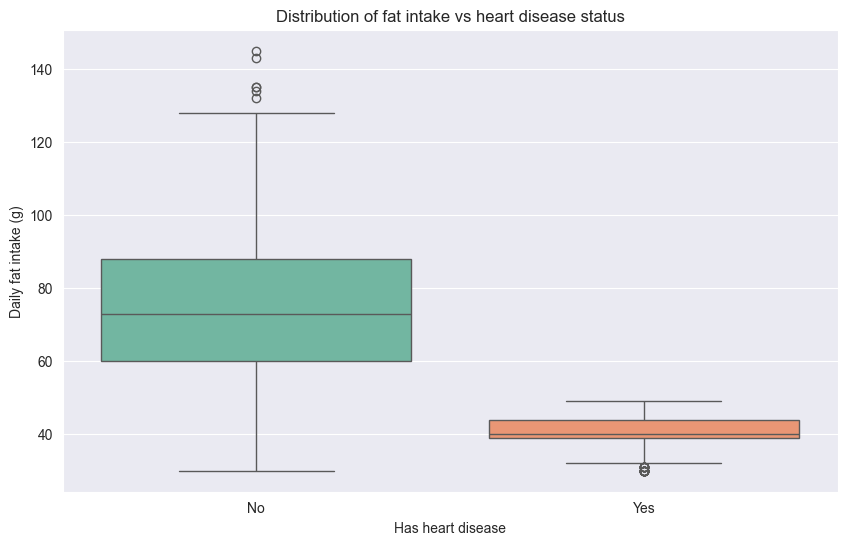

In [80]:
# Separate the data into two groups
group_sick = macros_dataset[macros_dataset['heart_disease'] == 1]['fat']
group_healthy = macros_dataset[macros_dataset['heart_disease'] == 0]['fat']

print(f"Mean fat intake (group with heart disease): {group_sick.mean():.2f} g")
print(f"Mean fat intake (group without heart disease): {group_healthy.mean():.2f} g")

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='heart_disease', y='fat', data=macros_dataset, palette='Set2', hue='heart_disease', legend=False)
plt.title('Distribution of fat intake vs heart disease status')
plt.xlabel('Has heart disease')
plt.ylabel('Daily fat intake (g)')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [81]:
# Perform Independent T-Test
t_stat, p_val = stats.ttest_ind(group_sick, group_healthy, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}") # Scientific notation for very small numbers

# Interpretation Logic
alpha = 0.05
if p_val < alpha:
    print("\nConclusion: Reject the Null Hypothesis (Significant Difference found).")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis.")

T-Statistic: -61.7403
P-Value: 0.0000e+00

Conclusion: Reject the Null Hypothesis (Significant Difference found).


### Interpretation of Hypothesis Test - Fat intake vs heart disease
The analysis reveals a significant difference, but in the opposite direction of what a causal hypothesis (High Fat -> Disease) would suggest. The group with heart disease has a significantly lower mean fat intake

#### Hypothesis Testing: Test if Fat intake is associated with Obese patients

Mean fat intake (group with obesity): 73.20 g
Mean fat intake (group without obesity): 68.73 g


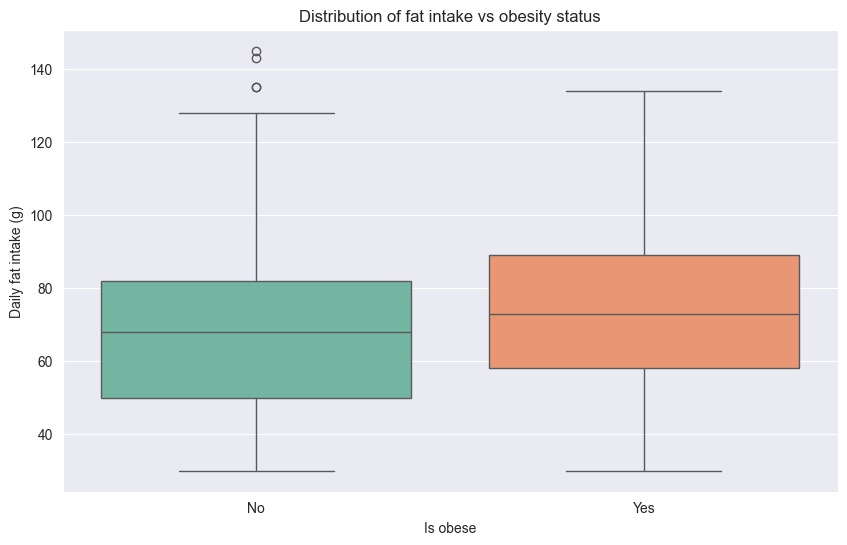

In [82]:
# Separate the data into two groups
group_sick = macros_dataset[macros_dataset['obesity'] == 1]['fat']
group_healthy = macros_dataset[macros_dataset['obesity'] == 0]['fat']

print(f"Mean fat intake (group with obesity): {group_sick.mean():.2f} g")
print(f"Mean fat intake (group without obesity): {group_healthy.mean():.2f} g")

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='obesity', y='fat', data=macros_dataset, palette='Set2', hue='obesity', legend=False)
plt.title('Distribution of fat intake vs obesity status')
plt.xlabel('Is obese')
plt.ylabel('Daily fat intake (g)')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [83]:
# Perform Independent T-Test
t_stat, p_val = stats.ttest_ind(group_sick, group_healthy, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}") # Scientific notation for very small numbers

# Interpretation Logic
alpha = 0.05
if p_val < alpha:
    print("\nConclusion: Reject the Null Hypothesis (Significant Difference found).")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis.")


T-Statistic: 3.4754
P-Value: 5.4888e-04

Conclusion: Reject the Null Hypothesis (Significant Difference found).


### Interpretation of Hypothesis Test - Fat intake vs obesity
The analysis reveals a slight difference but not significant to compare to the threshold (High Fat -> Obesity). The group without obesity has a slightly lower mean fat intake but not enough to accept the null hypothesis. Therefore, we reject the null hypothesis and can conclude that fat intake has no significant affect on obesity.

#### Regression Analysis

In [84]:
# Linear Regression model predicting BMI to check R-Squared and Homoscedasticity.
# Using BMI because it is a continuous variable, suitable for R-squared analysis.

features = [
    'daily_calorie_target', 'protein', 'sugar', 'sodium', 
    'carbohydrates', 'fiber', 'fat', 'activity_level', 'dietary_preference'
]

X = macros_dataset[features].copy()
y = macros_dataset['bmi']

# 2. Encode Categorical Variables
le = LabelEncoder()
for col in ["activity_level", "dietary_preference"]:
    X[col] = le.fit_transform(X[col])

# 3. Standardize/Scale the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 4. Add Constant for OLS (Intercept)
X_const = sm.add_constant(X_scaled)

# 5. Fit the OLS Regression Model
model = sm.OLS(y, X_const).fit()

# Print basic summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     8.050
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           1.37e-08
Time:                        16:43:37   Log-Likelihood:                -5543.2
No. Observations:                1698   AIC:                         1.110e+04
Df Residuals:                    1691   BIC:                         1.114e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   26.0486 

R-Squared: 0.0278

Interpretation: An R-Squared of 2.78% indicates that dietary features alone weakly predict current BMI in this dataset.


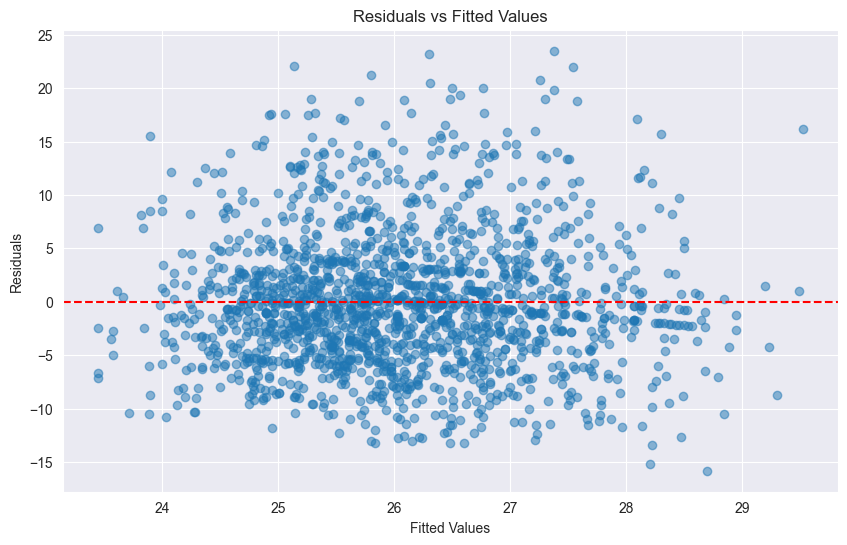

In [85]:
# R Squared
r_squared = model.rsquared

print(f"R-Squared: {r_squared:.4f}")

print("\nInterpretation: An R-Squared of {:.2f}% indicates that dietary features alone weakly predict current BMI in this dataset.".format(r_squared*100))

# Homoscedasticity check
# Homoscedasticity assumes that error (residuals) are equal across the regression line.
residuals = model.resid
plt.figure(figsize=(10, 6))
plt.scatter(model.fittedvalues, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

Optimization terminated successfully.
         Current function value: 0.447718
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          heart_disease   No. Observations:                 1698
Model:                          Logit   Df Residuals:                     1696
Method:                           MLE   Df Model:                            1
Date:                Tue, 25 Nov 2025   Pseudo R-squ.:                 0.01860
Time:                        16:43:38   Log-Likelihood:                -760.22
converged:                       True   LL-Null:                       -774.63
Covariance Type:            nonrobust   LLR p-value:                 7.953e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5831      0.206    -12.562      0.000      -2.986      -2.180
ages           0.0218      0.

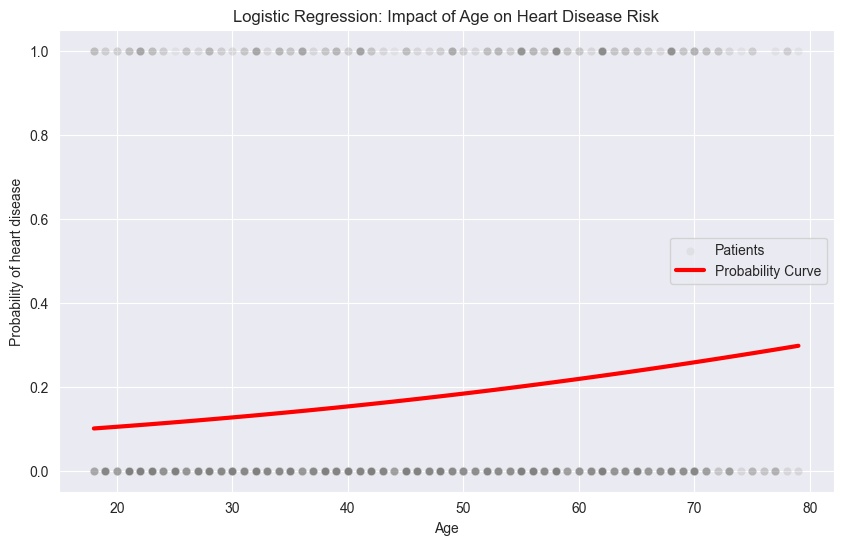


Pseudo R-Squared: 0.0186
Conclusion: Age has a SIGNIFICANT impact on Heart Disease.


In [86]:
# Logistic Regression on Age vs Heart Disease ---

y_disease = macros_dataset['heart_disease'].astype(int)   # Target: 0 or 1
X_age = sm.add_constant(macros_dataset['ages'])            # Feature: Age

# Fit Logistic Regression Model
logit_model = sm.Logit(y_disease, X_age).fit()

# Print Summary
print(logit_model.summary())

# Calculate Odds Ratio (Impact)
params = logit_model.params
conf = logit_model.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['5%', '95%', 'Odds Ratio']
print("\nOdds Ratios (Impact Factor):")
print(np.exp(conf))

# Visualization: Probability of Heart Disease vs Age
plt.figure(figsize=(10, 6))

# Scatter plot of actual data (0 or 1)
sns.scatterplot(x=macros_dataset['ages'], y=y_disease, alpha=0.1, color='gray', label='Patients')
# Sigmoid Curve (Predicted Probability)
ages_sorted = np.sort(macros_dataset['ages'].unique())
X_test = sm.add_constant(ages_sorted)
predicted_probs = logit_model.predict(X_test)

plt.plot(ages_sorted, predicted_probs, color='red', linewidth=3, label='Probability Curve')
plt.xlabel('Age')
plt.ylabel('Probability of heart disease')
plt.title('Logistic Regression: Impact of Age on Heart Disease Risk')
plt.legend()
plt.show()

# Interpretation
p_value_age = logit_model.pvalues['ages']
pseudo_r2 = logit_model.prsquared

print(f"\nPseudo R-Squared: {pseudo_r2:.4f}")
if p_value_age < 0.05:
    print("Conclusion: Age has a SIGNIFICANT impact on Heart Disease.")
else:
    print("Conclusion: Age does NOT have a significant impact on Heart Disease.")

#### Univariate Linear Regression (Manual Gradient Descent)

Objective: Predict BMI using Daily Calorie Target by implementing Gradient Descent

We use Daily Calorie Target as our feature ($X$) because it is a continuous variable likely correlated with body mass.

In [87]:
# Select Feature and Target
# X = Daily Calorie Target, y = BMI
X_raw = macros_dataset[['daily_calorie_target']].values
y_raw = macros_dataset['bmi'].values

# Scale the data (Crucial for Gradient Descent stability)
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X_raw).flatten()
y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1358
Testing samples: 340


#### Implement Gradient Descent

We iteratively update the weight ($w$) and bias ($b$) to minimize the Mean Squared Error (MSE).

In [88]:
# Hyperparameters
learning_rate = 0.01
epochs = 1000
n = len(X_train)

# Initialize Parameters
w_gd = 0.0
b_gd = 0.0
loss_history = []

# Training Loop
for epoch in range(epochs):
    # 1. Prediction
    y_hat = w_gd * X_train + b_gd
    
    # 2. Calculate Gradients
    # Derivative of MSE w.r.t w: (-2/n) * sum(x * (y - y_hat))
    grad_w = (-2/n) * np.sum((y_train - y_hat) * X_train)
    
    # Derivative of MSE w.r.t b: (-2/n) * sum(y - y_hat)
    grad_b = (-2/n) * np.sum(y_train - y_hat)
    
    # 3. Update Parameters
    w_gd -= learning_rate * grad_w
    b_gd -= learning_rate * grad_b
    
    # 4. Record Loss (MSE)
    mse_epoch = mean_squared_error(y_train, y_hat)
    loss_history.append(mse_epoch)

print(f"Final Parameters (Scaled): \nw = {w_gd:.4f}  \nb = {b_gd:.4f}  \nFinal MSE = {loss_history[-1]:.4f}")

Final Parameters (Scaled): 
w = 0.0703  
b = -0.0012  
Final MSE = 0.9790


#### Visualize Convergence & Regression Line

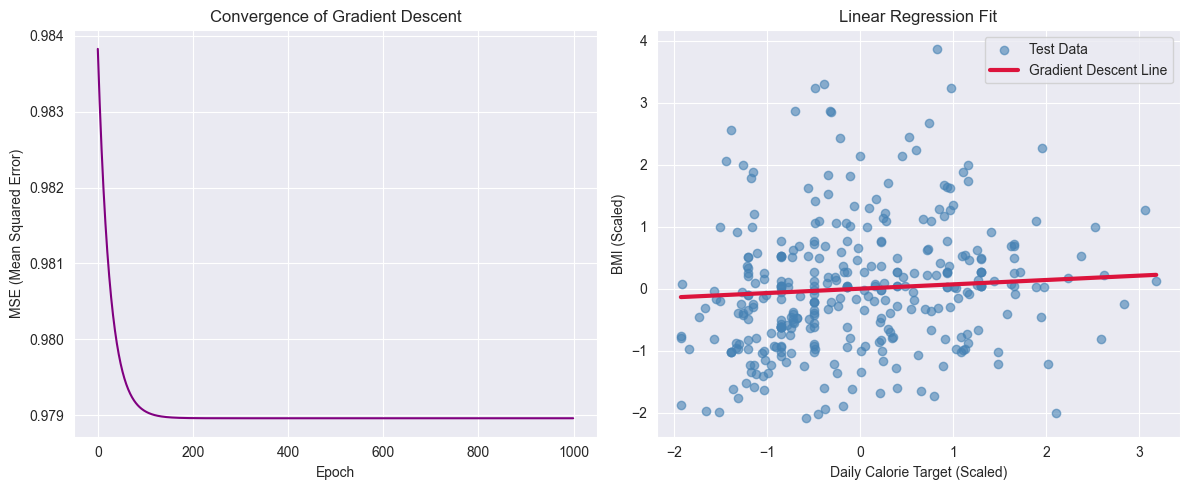

In [89]:
# Plot 1: Convergence (Loss over Epochs)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, color='purple')
plt.xlabel('Epoch')
plt.ylabel('MSE (Mean Squared Error)')
plt.title('Convergence of Gradient Descent')

# Plot 2: Best Fit Line vs Data
plt.subplot(1, 2, 2)

# Scatter plot of Test Data
plt.scatter(X_test, y_test, color='steelblue', alpha=0.6, label='Test Data')

# Calculate Line points
x_range = np.linspace(X_test.min(), X_test.max(), 100)
y_line = w_gd * x_range + b_gd

plt.plot(x_range, y_line, color='crimson', linewidth=3, label='Gradient Descent Line')
plt.xlabel('Daily Calorie Target (Scaled)')
plt.ylabel('BMI (Scaled)')
plt.title('Linear Regression Fit')
plt.legend()

plt.tight_layout()
plt.show()

#### Verify with Scikit-Learn `SGDRegressor`

Comparing our manual implementation with Scikit-Learn `SGDRegressor`

In [90]:
# Reshape for Sklearn (requires 2D array)
X_train_sk = X_train.reshape(-1, 1)
X_test_sk = X_test.reshape(-1, 1)

# Initialize SGDRegressor
sgd = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.01, random_state=42)
sgd.fit(X_train_sk, y_train)

y_pred_sgd = sgd.predict(X_test_sk)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)

print("--- Comparison ---")
print(f"Manual GD MSE:   {loss_history[-1]:.5f}")
print(f"Sklearn SGD MSE: {mse_sgd:.5f}")
print(f"Difference:      {abs(loss_history[-1] - mse_sgd):.5f}")

if abs(loss_history[-1] - mse_sgd) < 0.01:
    print("\nResult: Our manual implementation matches the Scikit-Learn library!")
else:
    print("\nResult: There is a slight divergence (expected due to solver differences).")

--- Comparison ---
Manual GD MSE:   0.97896
Sklearn SGD MSE: 1.03845
Difference:      0.05949

Result: There is a slight divergence (expected due to solver differences).


#### TODO: Add scikit learn documentation references and prof's github repository for the gradient descent manual implementation

# References:
Google. (2025). Gemini (November 25 version) [Large language model]. https://gemini.google.com/

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt & J. Millman (Eds.), Proceedings of the 9th Python in Science Conference (pp. 51–56). https://pandas.pydata.org/

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://scikit-learn.org/

Python Software Foundation. (2025). Python (Version 3.13) [Computer software]. https://www.python.org/

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. In S. van der Walt & J. Millman (Eds.), Proceedings of the 9th Python in Science Conference (pp. 92–96). https://www.statsmodels.org/

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., ... & SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. Nature Methods, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2

Waskom, M. L. (2021). seaborn: statistical data visualization. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021